# 05 · Modelo XGBoost con features de lag
**Proyecto ML — Bizkaibus 2026**

XGBoost trata la predicción de series temporales como un problema de regresión supervisada,
usando features de lag, rolling means y variables temporales como predictores.

**Ventaja**: Captura interacciones no lineales entre líneas y períodos.  
**Estrategia**: Un modelo global (todas las líneas), con `linea` codificada como feature.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

train = pd.read_csv('../data/train.csv', parse_dates=['fecha'])
test  = pd.read_csv('../data/test.csv',  parse_dates=['fecha'])
df_all = pd.read_csv('../data/train_merged.csv', parse_dates=['fecha'])

print(f"Train: {train.shape} | Test: {test.shape}")


Train: (5712, 31) | Test: (1140, 31)


## 1. Preparación de features

In [2]:
# Codificación de línea como entero
le = LabelEncoder()
df_all['linea_enc'] = le.fit_transform(df_all['linea'])

# Features para XGBoost
FEATURE_COLS = [
    'linea_enc', 'mes', 'año', 'trimestre',
    'mes_sin', 'mes_cos',
    'flag_covid', 'flag_subsidio',
    'lag_1', 'lag_3', 'lag_12',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12',
]
TARGET = 'viajeros_total'

# Filtrar filas con NaN en lags (primeras filas por línea)
df_model = df_all.dropna(subset=FEATURE_COLS).copy()
train_m = df_model[df_model['año'] <= 2024]
test_m  = df_model[df_model['año'] == 2025]

X_train = train_m[FEATURE_COLS]
y_train = train_m[TARGET]
X_test  = test_m[FEATURE_COLS]
y_test  = test_m[TARGET]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Features: {FEATURE_COLS}")


X_train: (4506, 14) | X_test: (1131, 14)
Features: ['linea_enc', 'mes', 'año', 'trimestre', 'mes_sin', 'mes_cos', 'flag_covid', 'flag_subsidio', 'lag_1', 'lag_3', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12']


## 2. Entrenamiento y evaluación

In [3]:
# Modelo XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

y_pred_xgb = np.clip(xgb_model.predict(X_test), 0, None)

mae  = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape = np.mean(np.abs((y_test.values - y_pred_xgb) / (y_test.values + 1e-9))) * 100

print(f"\n=== XGBoost — Métricas globales (test 2025) ===")
print(f"  MAE:  {mae:,.0f} viajeros")
print(f"  RMSE: {rmse:,.0f} viajeros")
print(f"  MAPE: {mape:.1f}%")


[0]	validation_0-rmse:31063.11125
[100]	validation_0-rmse:5690.81180
[200]	validation_0-rmse:6003.19243
[300]	validation_0-rmse:6125.67861
[400]	validation_0-rmse:6218.39806
[499]	validation_0-rmse:6289.23060

=== XGBoost — Métricas globales (test 2025) ===
  MAE:  3,263 viajeros
  RMSE: 6,289 viajeros
  MAPE: 3868005747889.8%


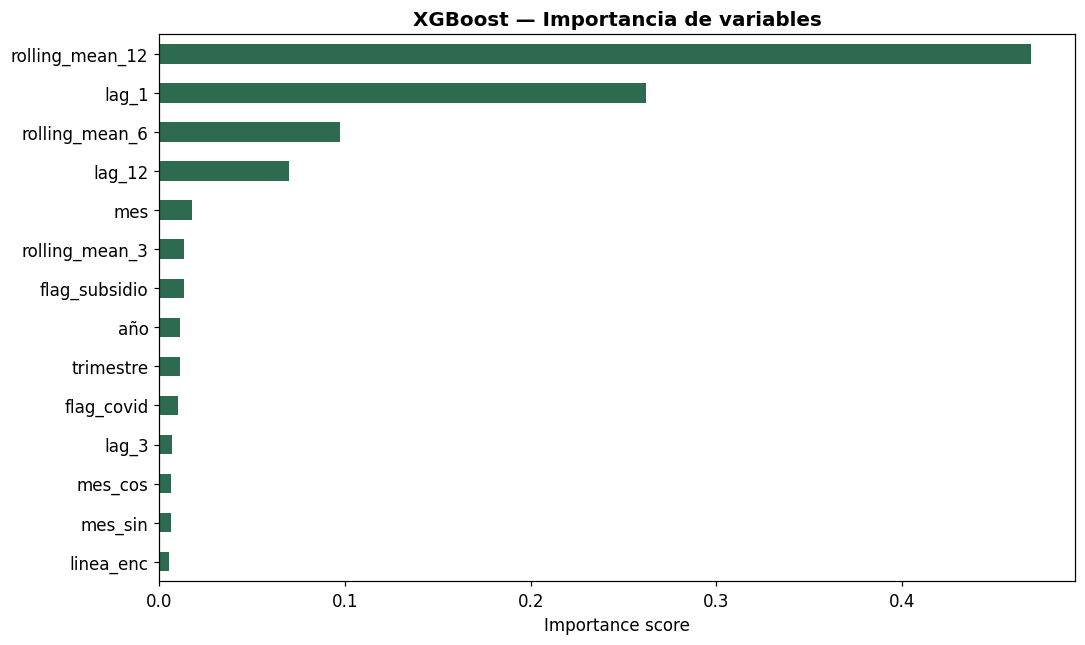

In [4]:
# Importancia de features
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, color='#2d6a4f')
ax.set_title('XGBoost — Importancia de variables', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()


In [5]:
# Métricas por línea
test_m = test_m.copy()
test_m['y_pred'] = y_pred_xgb

metricas_xgb = []
for linea in test_m['linea'].unique():
    sub = test_m[test_m['linea'] == linea]
    if len(sub) < 3: continue
    mae_l  = mean_absolute_error(sub[TARGET], sub['y_pred'])
    rmse_l = np.sqrt(mean_squared_error(sub[TARGET], sub['y_pred']))
    mape_l = np.mean(np.abs((sub[TARGET].values - sub['y_pred'].values) / (sub[TARGET].values + 1e-9))) * 100
    metricas_xgb.append({'linea': linea, 'mae': mae_l, 'rmse': rmse_l, 'mape': mape_l})

metricas_xgb_df = pd.DataFrame(metricas_xgb)
metricas_xgb_df.to_csv('../data/metricas_xgboost.csv', index=False)
print("=== Métricas XGBoost por línea ===")
print(metricas_xgb_df[['mae','rmse','mape']].describe().round(2))


=== Métricas XGBoost por línea ===
            mae      rmse          mape
count     95.00     95.00  9.500000e+01
mean    3241.64   4561.69  3.837469e+12
std     3081.60   4316.75  1.262446e+13
min      106.77    136.02  3.990000e+00
25%      950.21   1215.95  9.920000e+00
50%     2302.49   3346.45  1.261000e+01
75%     4203.22   6142.23  1.157000e+02
max    13652.09  18025.98  8.770596e+13


## 3. Predicción 2026

In [6]:
# Para predecir 2026 con XGBoost necesitamos construir features de lag
# usando los datos reales de 2025 como base

predicciones_xgb_2026 = []

for linea in df_all['linea'].unique():
    serie = df_all[df_all['linea'] == linea].sort_values('fecha')[['fecha','viajeros_total']].copy()
    linea_enc = le.transform([linea])[0]
    
    # Extender con 12 meses de 2026 usando predicciones iterativas
    historia = serie['viajeros_total'].tolist()
    fechas_hist = serie['fecha'].tolist()
    
    for mes_offset in range(12):
        fecha_pred = pd.Timestamp('2026-01-01') + pd.DateOffset(months=mes_offset)
        mes = fecha_pred.month
        año = 2026
        
        if len(historia) < 12:
            continue
        
        lag_1  = historia[-1]
        lag_3  = historia[-3]
        lag_12 = historia[-12]
        rm3  = np.mean(historia[-3:])
        rm6  = np.mean(historia[-6:])
        rm12 = np.mean(historia[-12:])
        
        features = pd.DataFrame([{
            'linea_enc': linea_enc, 'mes': mes, 'año': año,
            'trimestre': (mes - 1) // 3 + 1,
            'mes_sin': np.sin(2 * np.pi * mes / 12),
            'mes_cos': np.cos(2 * np.pi * mes / 12),
            'flag_covid': 0, 'flag_subsidio': 1,
            'lag_1': lag_1, 'lag_3': lag_3, 'lag_12': lag_12,
            'rolling_mean_3': rm3, 'rolling_mean_6': rm6, 'rolling_mean_12': rm12,
        }])
        
        pred = max(0, float(xgb_model.predict(features)[0]))
        historia.append(pred)
        
        predicciones_xgb_2026.append({
            'linea': linea, 'fecha': fecha_pred,
            'año': 2026, 'mes': mes, 'viajeros_pred_xgb': pred,
        })

pred_xgb_2026_df = pd.DataFrame(predicciones_xgb_2026)
pred_xgb_2026_df.to_csv('../data/predicciones_2026_xgboost.csv', index=False)
print(f"✓ Predicciones XGBoost 2026: {pred_xgb_2026_df.shape}")
total_xgb = pred_xgb_2026_df.groupby('fecha')['viajeros_pred_xgb'].sum()
print(f"Total predicho 2026: {total_xgb.sum()/1e6:.2f}M viajeros")


✓ Predicciones XGBoost 2026: (1200, 5)
Total predicho 2026: 36.83M viajeros
